In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

perf = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

print(nav.shape)
print(perf.shape)

(46000, 3)
(40, 19)


In [3]:
print(nav.columns.tolist())
print(perf.columns.tolist())

['amfi_code', 'date', 'nav']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [4]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [5]:
cagr_data = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].sort_values("date")

    start_nav = temp["nav"].iloc[0]
    end_nav = temp["nav"].iloc[-1]

    years = (
        (temp["date"].max() -
         temp["date"].min()).days
        / 365
    )

    cagr = (
        (end_nav/start_nav)
        ** (1/years)
    ) - 1

    cagr_data.append(
        [fund,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [6]:
rf = 0.065

sharpe = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    annual_return = r.mean()*252

    annual_std = r.std()*np.sqrt(252)

    sharpe_ratio = (
        annual_return-rf
    ) / annual_std

    sharpe.append(
        [fund,sharpe_ratio]
    )

sharpe_df = pd.DataFrame(
    sharpe,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
).head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [7]:
sortino = []

for fund in nav["amfi_code"].unique():

    r = nav[
        nav["amfi_code"] == fund
    ]["daily_return"].dropna()

    downside = r[r < 0]

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    annual_return = r.mean()*252

    ratio = (
        annual_return-rf
    ) / downside_std

    sortino.append(
        [fund,ratio]
    )

sortino_df = pd.DataFrame(
    sortino,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [8]:
drawdowns = []

for fund in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp[
        "drawdown"
    ].min()

    drawdowns.append(
        [fund,max_dd]
    )

dd_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

In [9]:
print(
    pd.read_csv(
        "../data/raw/benchmark.csv"
    ).columns
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/benchmark.csv'

In [10]:
import os

print(os.listdir("../data/raw"))

['01_fund_master.csv', '02_nav_history.csv', '03_aum_by_fund_house.csv', '04_monthly_sip_inflows.csv', '05_category_inflows.csv', '06_industry_folio_count.csv', '07_scheme_performance.csv', '08_investor_transactions.csv', '09_portfolio_holdings.csv', '10_benchmark_indices.csv', 'hdfc_top100_nav.csv']


In [11]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())

benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [12]:
alpha_beta = []

for fund in nav["amfi_code"].unique():

    temp = merged[
        merged["amfi_code"] == fund
    ]

    slope, intercept, r, p, se = (
        linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [fund,alpha,beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

NameError: name 'merged' is not defined

In [13]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [14]:
print("merged" in globals())

False


In [15]:
temp = merged[
    merged["amfi_code"] == fund
]

NameError: name 'merged' is not defined

In [16]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["benchmark_return"] = (
    benchmark["index_value"]
    .pct_change()
)

KeyError: 'index_value'

In [17]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(benchmark.columns.tolist())

['date', 'index_name', 'close_value']


In [18]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [19]:
benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [20]:
print(
    benchmark["index_name"].unique()
)

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [21]:
nifty100 = benchmark[
    benchmark["index_name"] == "Nifty 100"
].copy()

In [22]:
nifty100["date"] = pd.to_datetime(
    nifty100["date"]
)

nifty100 = nifty100.sort_values(
    "date"
)

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

In [23]:
merged = nav.merge(
    nifty100[
        ["date","benchmark_return"]
    ],
    on="date",
    how="inner"
)

In [24]:
print(merged.head())

Empty DataFrame
Columns: [amfi_code, date, nav, daily_return, benchmark_return]
Index: []


In [25]:
from scipy.stats import linregress

alpha_beta = []

for fund in merged["amfi_code"].unique():

    temp = merged[
        merged["amfi_code"] == fund
    ].dropna()

    if len(temp) < 30:
        continue

    slope, intercept, r, p, se = (
        linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [fund, alpha, beta]
    )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta


In [26]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [27]:
scorecard = (
    cagr_df
    .merge(
        sharpe_df,
        on="amfi_code"
    )
    .merge(
        alpha_beta_df,
        on="amfi_code"
    )
    .merge(
        dd_df,
        on="amfi_code"
    )
)

In [28]:
scorecard["score"] = (
    scorecard["cagr"].rank(pct=True)*30
    +
    scorecard["sharpe_ratio"].rank(pct=True)*25
    +
    scorecard["alpha"].rank(pct=True)*20
    +
    scorecard["max_drawdown"].rank(
        pct=True,
        ascending=False
    )*10
)

In [29]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [30]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [31]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=fund
    )

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

NameError: name 'top5_funds' is not defined

<Figure size 1200x600 with 0 Axes>

In [32]:
top5_funds = (
    perf.sort_values(
        "return_3yr_pct",
        ascending=False
    )["amfi_code"]
    .head(5)
    .tolist()
)

print(top5_funds)

[119598, 119599, 101207, 119095, 118634]


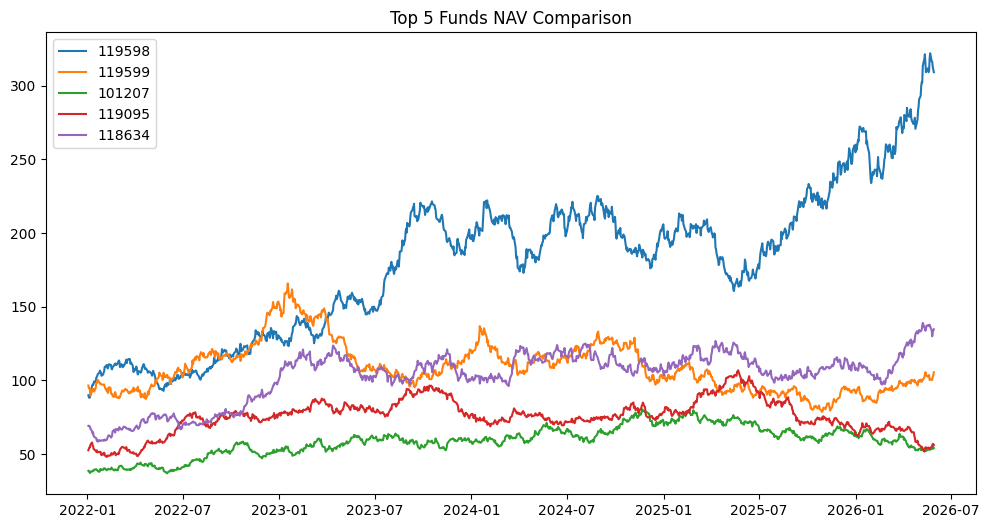

benchmark_comparison.png saved


In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(fund)
    )

plt.legend()

plt.title("Top 5 Funds NAV Comparison")

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("benchmark_comparison.png saved")

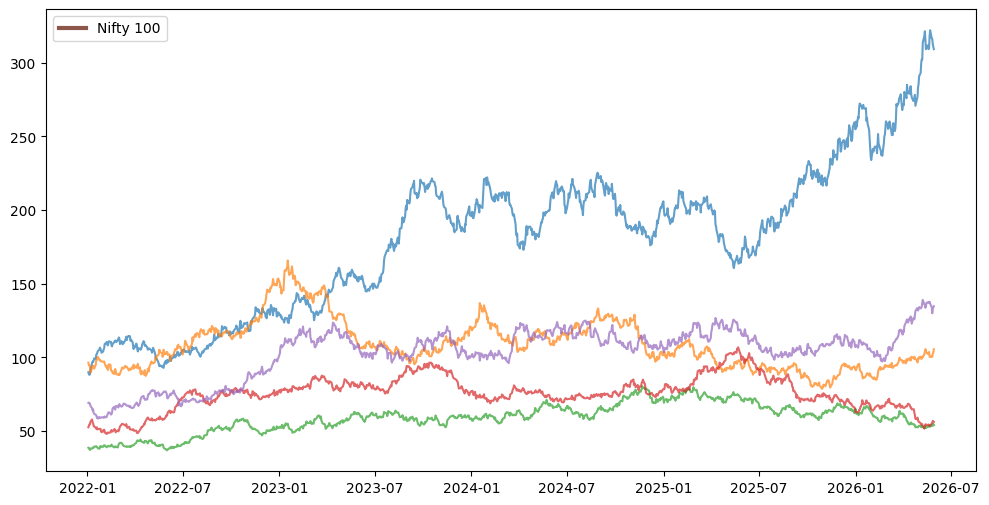

In [34]:
plt.figure(figsize=(12,6))

for fund in top5_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        alpha=0.7
    )

plt.plot(
    nifty100["date"],
    nifty100["close_value"],
    linewidth=3,
    label="Nifty 100"
)

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()